<a href="https://colab.research.google.com/github/Andrewstanchev/Python-projects/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# Changing work folder
%cd /content/drive/MyDrive/mate-academy/mate-homework/module_task/

# Uploading dataset
events_data = pd.read_csv("events.csv")
print(f"\nEvents_data head:\n\n{events_data.head()}")
products_data = pd.read_csv("products.csv")
print(f"\nProducts_data head:\n\n{products_data.head()}")
countries_data = pd.read_csv("countries.csv")
print(f"\ncountries_data head:\n\n{countries_data.head()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/mate-academy/mate-homework/module_task

Events_data head:

    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.7

Підключили файли. Перевірили чи все ок вивівши head() кожного файлу на екран

In [23]:
# Пропущені дані виявляємо та змінюємо
events_data.isna().sum()
events_data["Country Code"].fillna("Unknown", inplace=True)
events_data.dropna()
events_data["Units Sold"].fillna(events_data["Units Sold"].mean(), inplace=True)
print(f"\nПропуски в events_data:\n {events_data.isna().sum()}")
print(f"\nПропуски в products_data:\n {products_data.isna().sum()}")

missing_rows = countries_data[countries_data.isnull().any(axis=1)]
print(f"\nПропуски в countries_data:\n {missing_rows}")




Пропуски в events_data:
 Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64

Пропуски в products_data:
 id           0
item_type    0
dtype: int64

Пропуски в countries_data:
            name alpha-2 alpha-3  region          sub-region
8    Antarctica      AQ     ATA     NaN                 NaN
153     Namibia     NaN     NAM  Africa  Sub-Saharan Africa


/tmp/ipython-input-23-3836291826.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  events_data["Country Code"].fillna("Unknown", inplace=True)
/tmp/ipython-input-23-3836291826.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

Перевірили чи є пусті значення.
**1. Events.**    Побачили що 82 країни пусті та перейменували їх в "Unknown"(Не видаляли тому що це суттєва частина дата сету). Також 2 пустих значення в Units Sold ми замінили на середнє значення, тут числовий формат і небагато пропусків, тому йому дуже добре підходить ця опція.

**2. products.** Не має пропусків.

**3. Countries.** Пропуск по континенту Antarctica - він нам не потрібний тому не видаляємо. І в країні Namibia пропущений стовпчик alpha-2. Він нам не потрібний так як в основній таблиці не використовується, тому  теж не видаляємо



In [24]:
#Дивимось чи всі типи даних розпізнаються коректно.
print(events_data.info())
print(products_data.info())
print(countries_data.info())

# Змінюємо на дату та перевіряємо
events_data['Order Date'] = pd.to_datetime(events_data['Order Date'])
events_data['Ship Date'] = pd.to_datetime(events_data['Ship Date'])

print("\n\n Дані після зміни формату:\n")
print(events_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1330 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1

Бачимо що потрібно замінити в Order Date та Ship Date текстовий формат на дату.

In [25]:
# Перевіряємо дублікати
print("Дублікати у events_data:", events_data.duplicated().sum())
print("Дублікати у products_data:", products_data.duplicated().sum())
print("Дублікати у countries_data:", countries_data.duplicated().sum())

print("Дублікати Order ID у events_data:", events_data["Order ID"].duplicated().sum())
print("Дублікати id у products_data:", products_data["id"].duplicated().sum())
print("Дублікати name у countries_data:", countries_data["name"].duplicated().sum())

#Перевірка даних на аномалії
print(events_data.describe())

# Перевіряємо чи не має помилок(пробіли маленька буква і тд)
print(events_data["Order Priority"].value_counts())
print(events_data["Sales Channel"].value_counts())


events_data["Sales Channel"] = events_data["Sales Channel"].str.title()# Усуваємо online які починаються з маленької букви
events_data["Order Priority"] = events_data["Order Priority"].str.strip()  # Видаляємо пробіли на початку та в кінці

# Перевіряємо ще раз
print(events_data["Order Priority"].value_counts())
print(events_data["Sales Channel"].value_counts())


Дублікати у events_data: 0
Дублікати у products_data: 0
Дублікати у countries_data: 0
Дублікати Order ID у events_data: 0
Дублікати id у products_data: 0
Дублікати name у countries_data: 0
           Order ID                     Order Date  \
count  1.330000e+03                           1330   
mean   5.412048e+08  2013-10-12 06:09:12.180451072   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.190004e+08            2011-12-16 06:00:00   
50%    5.387164e+08            2013-10-17 00:00:00   
75%    7.544628e+08            2015-08-28 18:00:00   
max    9.998797e+08            2017-07-23 00:00:00   
std    2.573882e+08                            NaN   

                           Ship Date   Product ID   Units Sold   Unit Price  \
count                           1330  1330.000000  1330.000000  1330.000000   
mean   2013-11-06 00:46:33.383458816  5788.096241  4952.201807   264.893541   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%     

Дублікатів не було. Аномалій не було. Усунули зайві пробіли  та маленькі букви.

In [35]:
# Об'єднуємо events з products за Product ID
merged_df = events_data.merge(products_data, left_on="Product ID", right_on="id", how="left")

# Об'єднуємо з countries за Country Code
merged_df = merged_df.merge(countries_data, left_on="Country Code", right_on="alpha-3", how="left")

print(merged_df.head())  # Переглянемо перші рядки

merged_df.drop(columns=["id", "alpha-3"], inplace=True)  #Видаляємо непотрібні колонки
merged_df.rename(columns={"name": "Country Name", "item_type": "Product Type"}, inplace=True) #Перейменовуємо  колонки



    Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0  100640618 2014-10-08 2014-10-18              M          NOR        2103   
1  100983083 2016-08-11 2016-08-11              C          SRB        2103   
2  101025998 2014-07-18 2014-08-11              M      Unknown        7940   
3  102230632 2017-05-13 2017-06-13              L          MNE        2455   
4  103435266 2012-08-11 2012-09-18              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost    id  item_type  \
0        Online       650.0      205.70     117.11  2103     Cereal   
1       Offline      1993.0      205.70     117.11  2103     Cereal   
2        Online      4693.0      668.27     502.54  7940  Household   
3        Online      1171.0      109.28      35.84  2455    Clothes   
4       Offline      7648.0       47.45      31.79  1270  Beverages   

         name alpha-2 alpha-3  region       sub-region  
0      Norway      NO     NOR  Europe  Northern

In [ ]:
# Обчислюємо ключові метрики
total_orders = events_data["Order ID"].nunique()
print("Загальна кількість унікальних замовлень:", total_orders)

events_data["Total Revenue"] = events_data["Units Sold"] * events_data["Unit Price"]
total_revenue = events_data["Total Revenue"].sum()
print("Загальний прибуток компанії:", total_revenue)

unique_countries = events_data["Country Code"].nunique()
print("Кількість країн, де були продажі:", unique_countries)

avg_units_per_order = events_data["Units Sold"].mean()
print("Середня кількість товарів на замовлення:", avg_units_per_order)

sales_by_channel = events_data["Sales Channel"].value_counts()
print("Продажі за каналами:\n", sales_by_channel)

popular_product = merged_df['Product Type'].value_counts().idxmax()
print("Найбільш продаваний тип продукту:", popular_product)



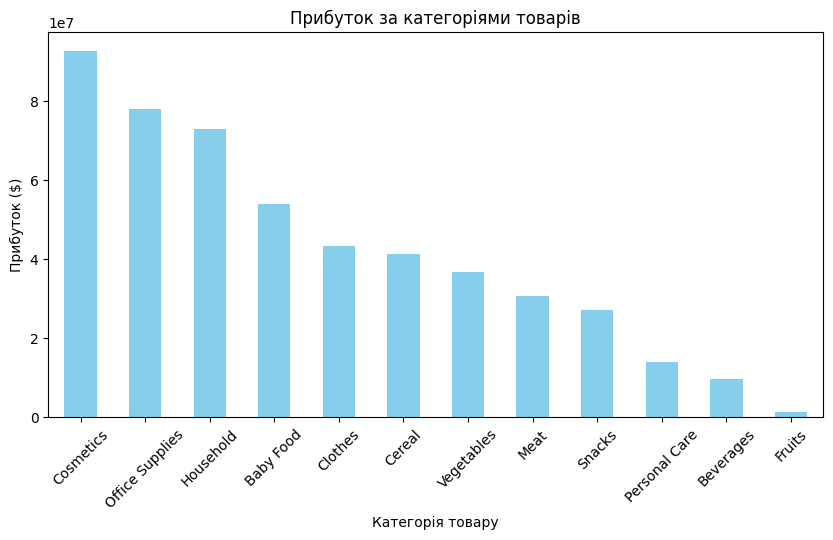

In [29]:
# Аналіз за категоріями товарів

# Додаємо колонку "Total Profit"
merged_df["Total Profit"] = (merged_df["Unit Price"] - merged_df["Unit Cost"]) * merged_df["Units Sold"]


# Групуємо дані за категоріями товарів
product_analysis = merged_df.groupby("Product Type")["Total Profit"].sum().sort_values(ascending=False)

# Візуалізуємо популярність товарів за прибутком
plt.figure(figsize=(10, 5))
product_analysis.plot(kind="bar", color="skyblue")
plt.title("Прибуток за категоріями товарів")
plt.xlabel("Категорія товару")
plt.ylabel("Прибуток ($)")
plt.xticks(rotation=45)
plt.show()



Як бачимо найбільший прибуток в категорії Cosmetics. Найменший - в Fruits.

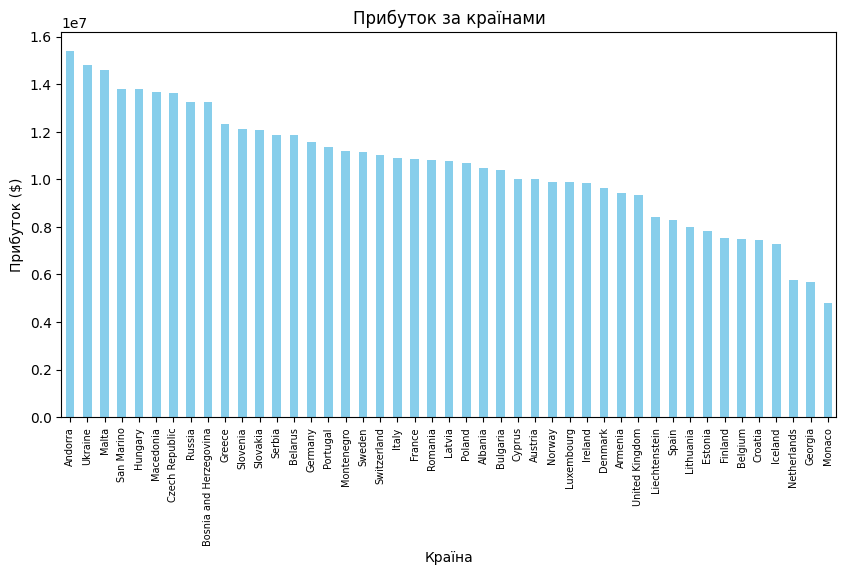

In [28]:
#Аналіз за країнами

# Групуємо продажі по країнах
geo_analysis = merged_df.groupby("Country Name")[["Total Profit", "Order ID"]].sum()

# Візуалізація прибутку по країнах
plt.figure(figsize=(10, 5))
geo_analysis["Total Profit"].sort_values(ascending=False).plot(kind="bar", color="skyblue")
plt.title("Прибуток за країнами")
plt.xlabel("Країна")
plt.ylabel("Прибуток ($)")
plt.xticks(rotation=90, fontsize = 7)
plt.show()

Продажі в Андору та Україну мають найбільший прибуток. Найменший в Монако. По країнам продажі розподілені достатньо рівномірно, діапазон прибутку від 6млн$ до майже 16млн в Андору.

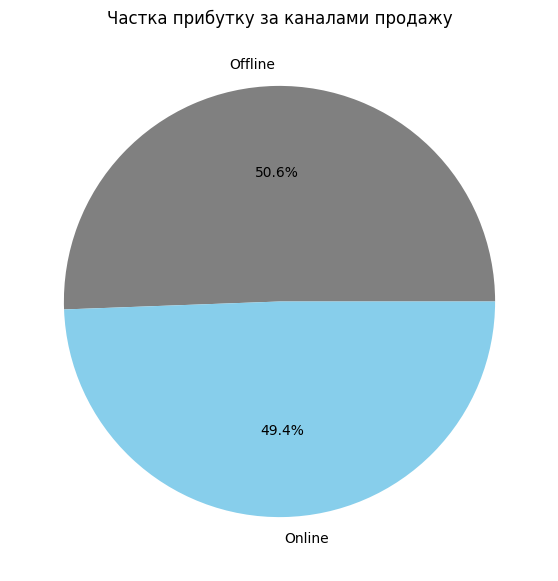

In [27]:
# Аналіз за каналами продажів (онлайн/офлайн)

channel_analysis = merged_df.groupby('Sales Channel')['Total Profit'].sum() #Групуємо за каналами(онлайн/офлайн)

# Будуємо кругову діаграму
plt.figure(figsize=(7, 7))
channel_analysis.plot(kind="pie", autopct="%1.1f%%", colors=["grey", "skyblue"])
plt.title("Частка прибутку за каналами продажу")
plt.ylabel("")
plt.show()

  Order Date  Ship Date  Delivery Time
0 2014-10-08 2014-10-18             10
1 2016-08-11 2016-08-11              0
2 2014-07-18 2014-08-11             24
3 2017-05-13 2017-06-13             31
4 2012-08-11 2012-09-18             38


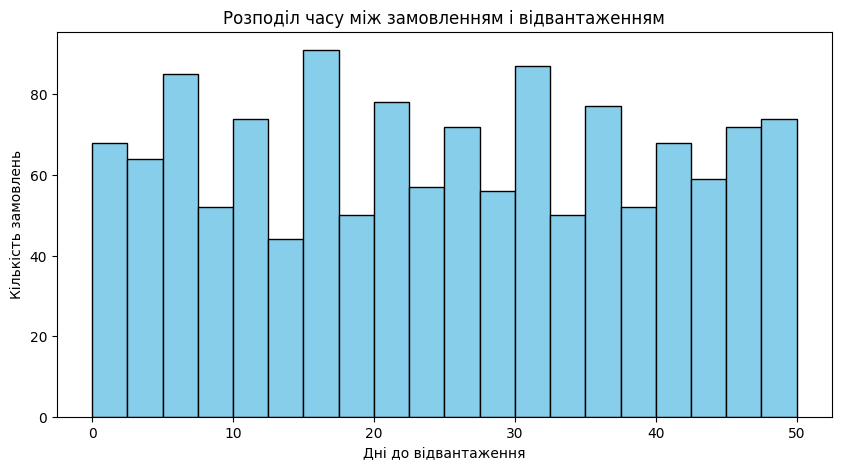

In [30]:
merged_df["Delivery Time"] = (merged_df["Ship Date"] - merged_df["Order Date"]).dt.days
print(merged_df[["Order Date", "Ship Date", "Delivery Time"]].head())  # Перевіряємо


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(merged_df["Delivery Time"], bins=20, color="skyblue", edgecolor="black")
plt.title("Розподіл часу між замовленням і відвантаженням")
plt.xlabel("Дні до відвантаження")
plt.ylabel("Кількість замовлень")
plt.show()

Як бачимо не має чіткого взаємозв'язку між тривалістю доставки та кількістю замовлень.Кількість замовлень достатньо рівномірно розподілена із доставкою від 0 до 50 днів.

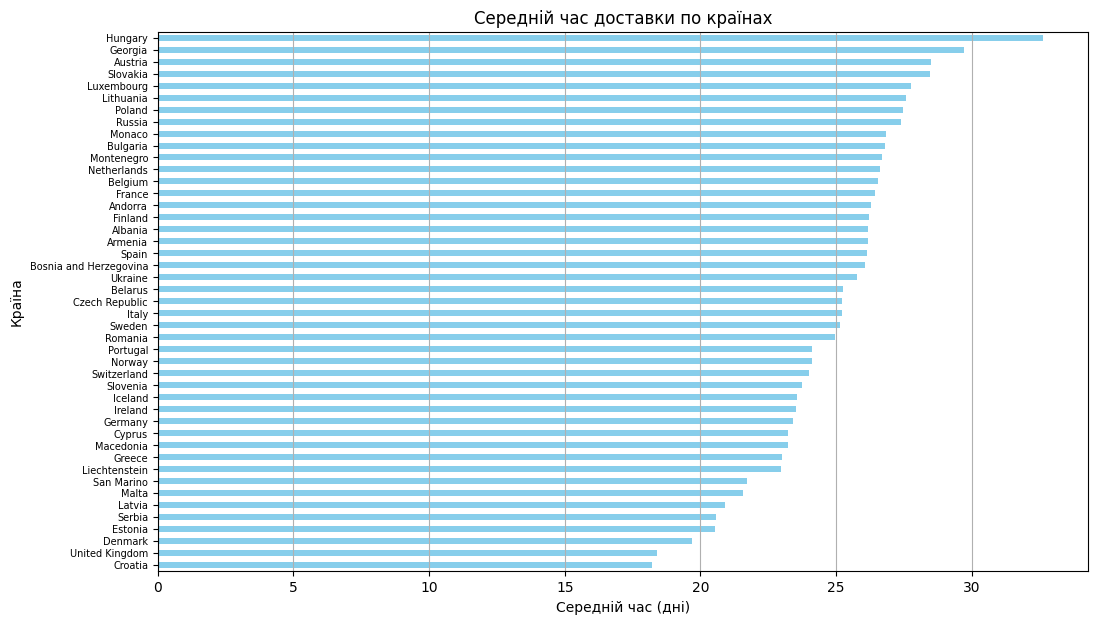

In [31]:
delivery_by_country = merged_df.groupby("Country Name")["Delivery Time"].mean().sort_values()

plt.figure(figsize=(12, 7))
delivery_by_country.plot(kind="barh", color="skyblue")
plt.title("Середній час доставки по країнах")
plt.xlabel("Середній час (дні)")
plt.ylabel("Країна")

plt.yticks(fontsize = 7)
plt.grid(visible=True, axis ='x')
plt.show()

Довше всього доставляють замовлення в Угорщину (Середній час доставки більше 30 днів). Найшвидше - у Хорватію(близько 18днів)

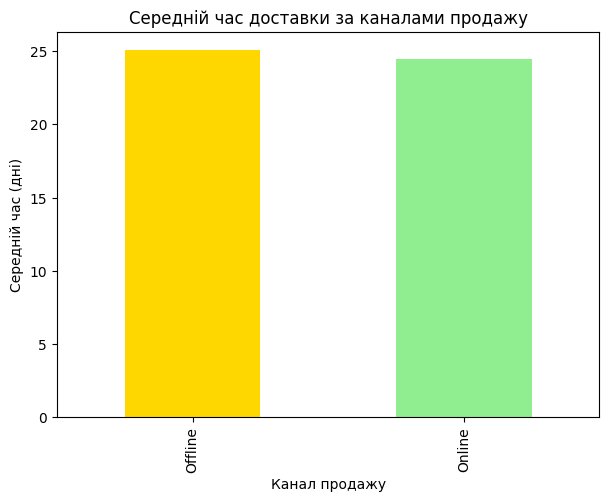

In [32]:
delivery_by_channel = merged_df.groupby("Sales Channel")["Delivery Time"].mean()

plt.figure(figsize=(7, 5))
delivery_by_channel.plot(kind="bar", color=["gold", "lightgreen"])
plt.title("Середній час доставки за каналами продажу")
plt.xlabel("Канал продажу")
plt.ylabel("Середній час (дні)")
plt.show()


Бачимо що між офлайн та онлайн замовленнями не має великої різниці у тривалості доставки.

region
Europe    24.777873
Asia      26.085366
Name: Delivery Time, dtype: float64


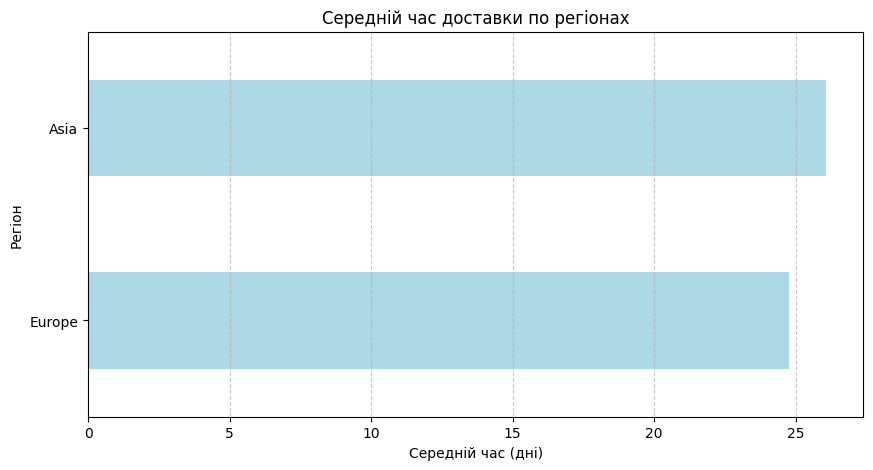

In [33]:
delivery_by_region = merged_df.groupby("region")["Delivery Time"].mean().sort_values()
print(delivery_by_region)

plt.figure(figsize=(10, 5))
delivery_by_region.plot(kind="barh", color="lightblue")
plt.title("Середній час доставки по регіонах")
plt.xlabel("Середній час (дні)")
plt.ylabel("Регіон")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

У нас тільки два регіони доставки і між ними не має суттєвої різниці

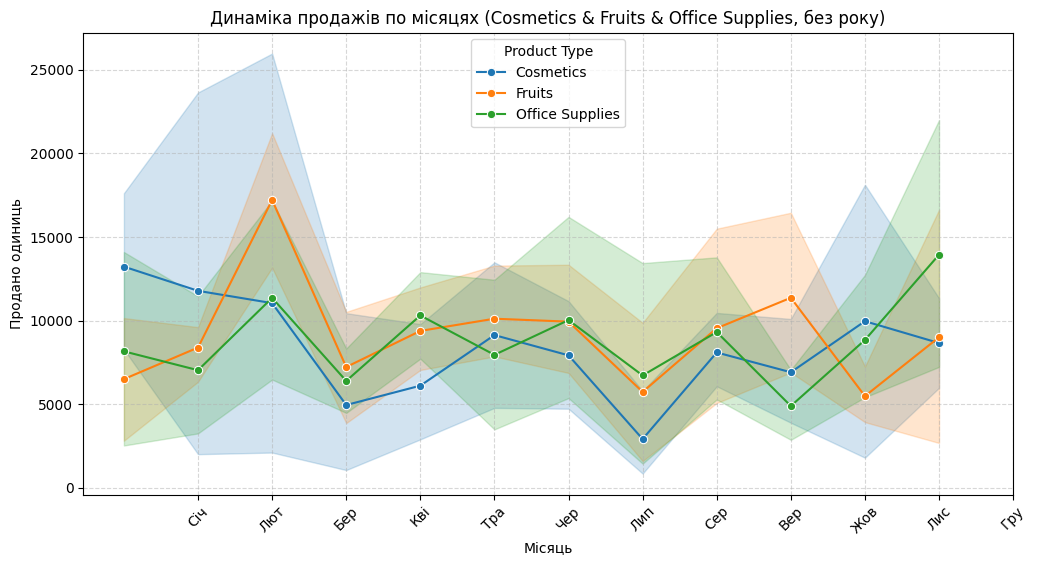

In [38]:
# Групуємо по місяцях та категоріях
sales_by_category = merged_df.groupby([merged_df["Order Date"].dt.to_period("M"), "Product Type"])["Units Sold"].sum().reset_index()
sales_by_category["Order Date"] = sales_by_category["Order Date"].astype(str)  # Перетворюємо в рядок

# Додаємо колонку з місяцем (без року)
sales_by_category["Month"] = sales_by_category["Order Date"].apply(lambda x: x[-2:])  # Беремо лише номер місяця

# Фільтруємо тільки три потрібні категорії
filtered_categories = ["Cosmetics", "Fruits", "Office Supplies"]
sales_filtered = sales_by_category[sales_by_category["Product Type"].isin(filtered_categories)]

# Візуалізація
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_filtered, x="Month", y="Units Sold", hue="Product Type", marker="o")
plt.title("Динаміка продажів по місяцях (Cosmetics & Fruits & Office Supplies, без року)")
plt.xlabel("Місяць")
plt.ylabel("Продано одиниць")
plt.xticks(rotation=45)
plt.xticks(range(1, 13), ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер", "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Бачимо що самий прибутковий місяць у нас березень незалежно від категорії.Самий неприбутковий - серпень теж незалежно від категорії

/tmp/ipython-input-42-436577346.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_country_march, x="Units Sold", y="Country Name", palette="coolwarm")


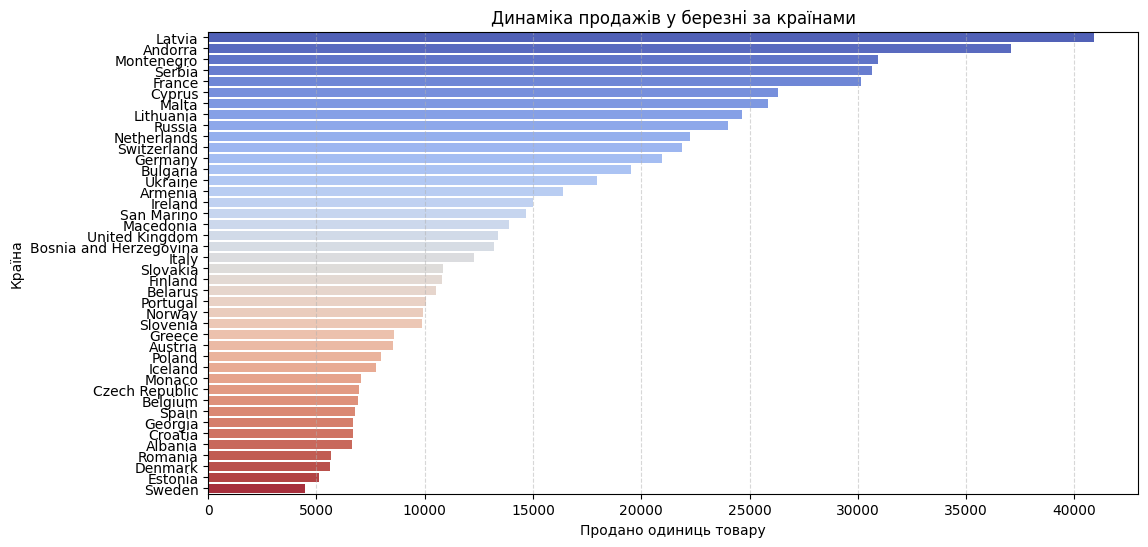

In [42]:
# Додаємо колонку з місяцем
merged_df["Month"] = merged_df["Order Date"].dt.month

# Фільтруємо тільки березень
march_sales = merged_df[merged_df["Month"] == 3]

# Групуємо продажі по країнах
sales_by_country_march = march_sales.groupby("Country Name")["Units Sold"].sum().reset_index()

# Сортуємо за кількістю продажів
sales_by_country_march = sales_by_country_march.sort_values(by="Units Sold", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=sales_by_country_march, x="Units Sold", y="Country Name", palette="coolwarm")
plt.title("Динаміка продажів у березні за країнами")
plt.xlabel("Продано одиниць товару")
plt.ylabel("Країна")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

Вивели динаміку продажів за самим піковим місяцем і бачимо що вона відрізняється від динаміки за весь час. Це нам говорить про те що у кожної країни є своя сезонність. В наступному графіку ми це продемонструємо.

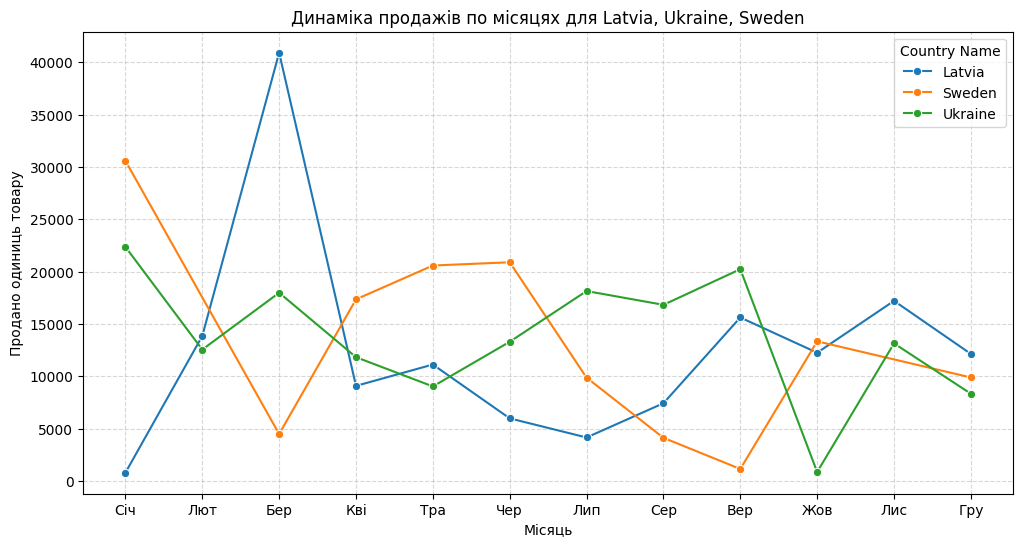

In [43]:
# Додаємо колонку "Month" (без року)
merged_df["Month"] = merged_df["Order Date"].dt.month

# Фільтруємо лише три країни
selected_countries = ["Latvia", "Ukraine", "Sweden"]
sales_by_selected_countries = merged_df[merged_df["Country Name"].isin(selected_countries)]

# Групуємо продажі по місяцях і країнах
sales_by_month_country = sales_by_selected_countries.groupby(["Month", "Country Name"])["Units Sold"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_by_month_country, x="Month", y="Units Sold", hue="Country Name", marker="o")
plt.title("Динаміка продажів по місяцях для Latvia, Ukraine, Sweden")
plt.xlabel("Місяць")
plt.ylabel("Продано одиниць товару")
plt.xticks(range(1, 13), ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер", "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Для кожної країни властива своя сезонність. У Латвії  пік в березні, а спад в січні. У Швеції в березні навпаки спад майже до нуля, а в січні пік. У України 2 піки - січень та вересень. А у жовтні спад майже до нуля

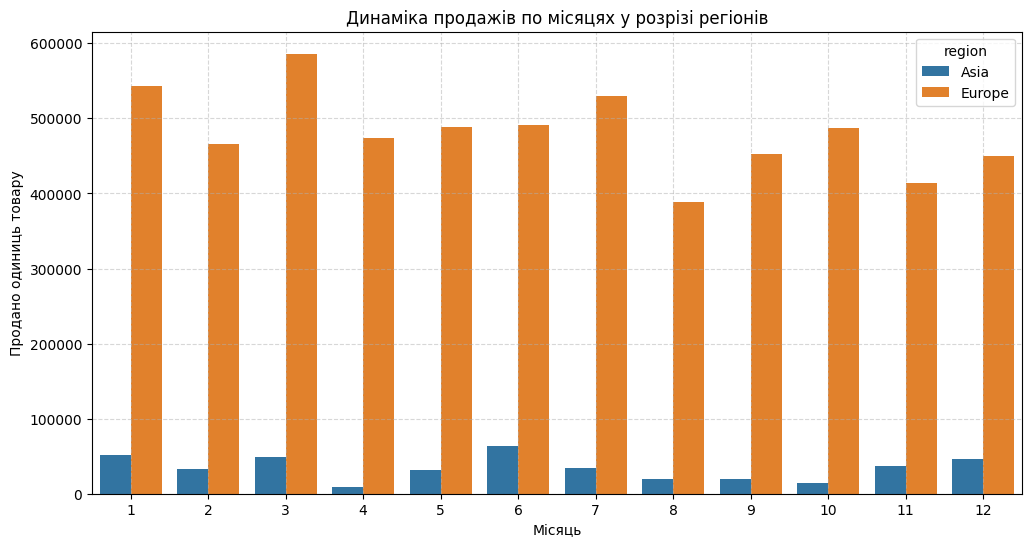

In [44]:


# Додаємо колонку "Month" (без року)
merged_df["Month"] = merged_df["Order Date"].dt.month

# Групуємо продажі по місяцях і регіонах
sales_by_month_region = merged_df.groupby(["Month", "region"])["Units Sold"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=sales_by_month_region, x="Month", y="Units Sold", hue="region")
plt.title("Динаміка продажів по місяцях у розрізі регіонів")
plt.xlabel("Місяць")
plt.ylabel("Продано одиниць товару")
#plt.xticks(range(1, 13), ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер", "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



Європа значно переважає Азію по продажам. По сезонності трохи відрізняються регіони. У Європи пік в березні, а у Азії в червні. У Європи спад в серпні, а  у Азії в квітні.

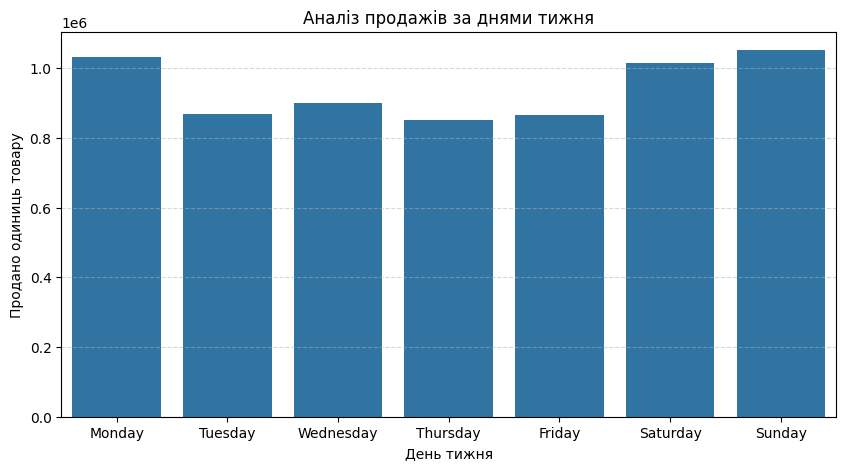

In [45]:
# Отримуємо назви днів тижня
merged_df["Day of Week"] = merged_df["Order Date"].dt.day_name()

# Групуємо продажі по днях тижня
sales_by_day = merged_df.groupby("Day of Week")["Units Sold"].sum().reset_index()

# Впорядкуємо дні тижня у правильному порядку
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day["Day of Week"] = pd.Categorical(sales_by_day["Day of Week"], categories=days_order, ordered=True)
sales_by_day = sales_by_day.sort_values("Day of Week")

plt.figure(figsize=(10, 5))
sns.barplot(data=sales_by_day, x="Day of Week", y="Units Sold")
plt.title("Аналіз продажів за днями тижня")
plt.xlabel("День тижня")
plt.ylabel("Продано одиниць товару")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

В загальному по всім товарам найбільше продажів у суботу, неділю, понеділок. Наступним кроком проаналізуємо по окремим категоріям

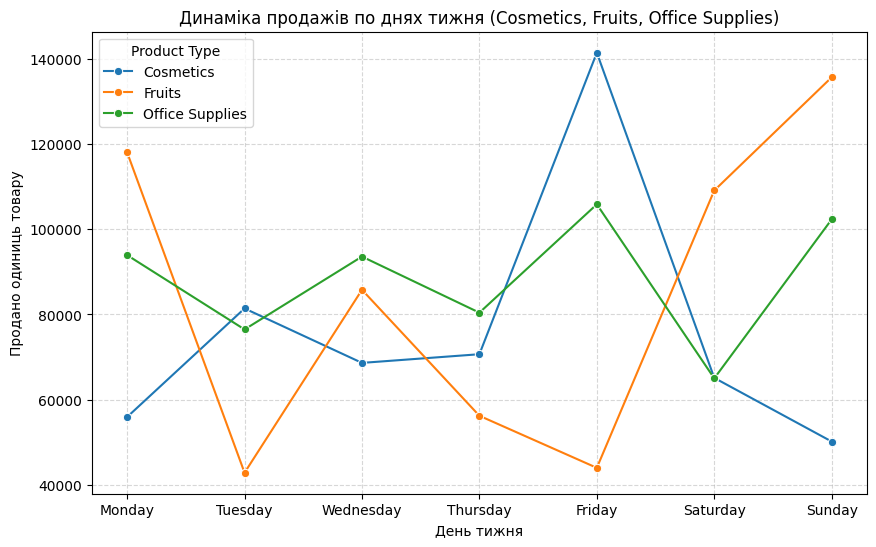

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Отримуємо назви днів тижня
merged_df["Day of Week"] = merged_df["Order Date"].dt.day_name()

# Фільтруємо лише потрібні категорії
filtered_categories = ["Cosmetics", "Fruits", "Office Supplies"]
sales_filtered = merged_df[merged_df["Product Type"].isin(filtered_categories)]

# Групуємо продажі по днях тижня та категоріях
sales_by_day_filtered = sales_filtered.groupby(["Day of Week", "Product Type"])["Units Sold"].sum().reset_index()

# Впорядкуємо дні тижня у правильному порядку
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_day_filtered["Day of Week"] = pd.Categorical(sales_by_day_filtered["Day of Week"], categories=days_order, ordered=True)
sales_by_day_filtered = sales_by_day_filtered.sort_values("Day of Week")

plt.figure(figsize=(10, 6))
sns.lineplot(data=sales_by_day_filtered, x="Day of Week", y="Units Sold", hue="Product Type", marker="o")
plt.title("Динаміка продажів по днях тижня (Cosmetics, Fruits, Office Supplies)")
plt.xlabel("День тижня")
plt.ylabel("Продано одиниць товару")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



Бачимо що на відміну від попереднього графіку найбільша категорія Cosmetics має навпаки найнижчі продажі у суботу-неділю-понеділок. Але явно виражений пік в п"ятницю. Фрукти піддаються загальній тенденції - на вихідних більше всього продажів.